# Tree Species Recognition with Transfer Learning

## Project goal
In this project, two ResNet architectures are trained to classify tree species from images.

The workflow is:
1. Explore the dataset
2. Prepare training, validation, and test data
3. Apply image preprocessing and augmentation
4. Train two different ResNet models using transfer learning
5. Compare their validation performance
6. Evaluate both models on the test set
7. Calculate accuracy, precision, recall, F1-score, and confusion matrices
8. Analyse top-n predictions
9. Inspect classification errors
10. Try an improvement and compare the results


In [1]:
# Imports and configuration

import os
import random
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Dataset paths (relative to the notebook/project working directory)
from pathlib import Path

DATA_DIR = Path("archive") / "tree"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

print("Dataset path:", DATA_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Device: cuda
Dataset path: archive\tree
Train exists: True
Validation exists: True
Test exists: True


## 1. Inspect the dataset


In [2]:
# Find image files and inspect the folder structure

valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

class_dirs = [
    d.name for d in TRAIN_DIR.iterdir()
    if d.is_dir()
]

class_dirs = sorted(class_dirs)

print("Number of class folders:", len(class_dirs))
print("Example classes:", class_dirs[:10])

image_counts = {}
for class_name in class_dirs:
    image_counts[class_name] = {
        "train": sum(
            1 for f in (TRAIN_DIR / class_name).iterdir()
            if f.is_file() and f.suffix.lower() in valid_extensions
        ),
        "val": sum(
            1 for f in (VAL_DIR / class_name).iterdir()
            if f.is_file() and f.suffix.lower() in valid_extensions
        ),
        "test": sum(
            1 for f in (TEST_DIR / class_name).iterdir()
            if f.is_file() and f.suffix.lower() in valid_extensions
        )
    }

class_counts = pd.DataFrame(image_counts).T
class_counts["total"] = class_counts.sum(axis=1)

display(class_counts.sort_values("total", ascending=False))

print("\nTotal images:", int(class_counts["total"].sum()))


Number of class folders: 23
Example classes: ['Acer palmatum', 'Cedrus deodara', 'Celtis sinensis', 'Cinnamomum camphora (Linn) Presl', 'Elaeocarpus decipiens', 'Flowering cherry', 'Ginkgo biloba', 'Koelreuteria paniculata', 'Lagerstroemia indica', 'Liquidambar formosana']


,train,val,test,total
Cinnamomum camphora (Linn) Presl,234,29,29,292
Ginkgo biloba,228,28,28,284
Sapindus saponaria,224,28,28,280
Koelreuteria paniculata,223,28,28,279
Magnolia grandiflora L,212,26,26,264
Platanus,193,24,24,241
Magnolia liliflora Desr,190,24,23,237
Celtis sinensis,188,24,23,235
Zelkova serrata,185,23,23,231
Liriodendron chinense,182,23,22,227



Total images: 4804


<Figure size 1200x600 with 0 Axes>

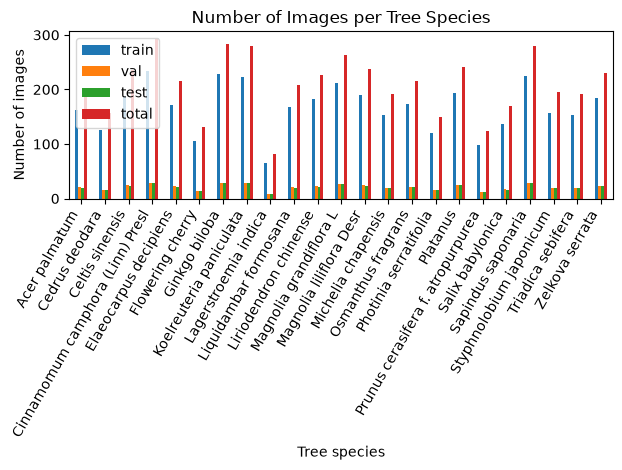

In [3]:
# Visualise the class distribution

plt.figure(figsize=(12, 6))
class_counts.plot(kind="bar")
plt.title("Number of Images per Tree Species")
plt.xlabel("Tree species")
plt.ylabel("Number of images")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

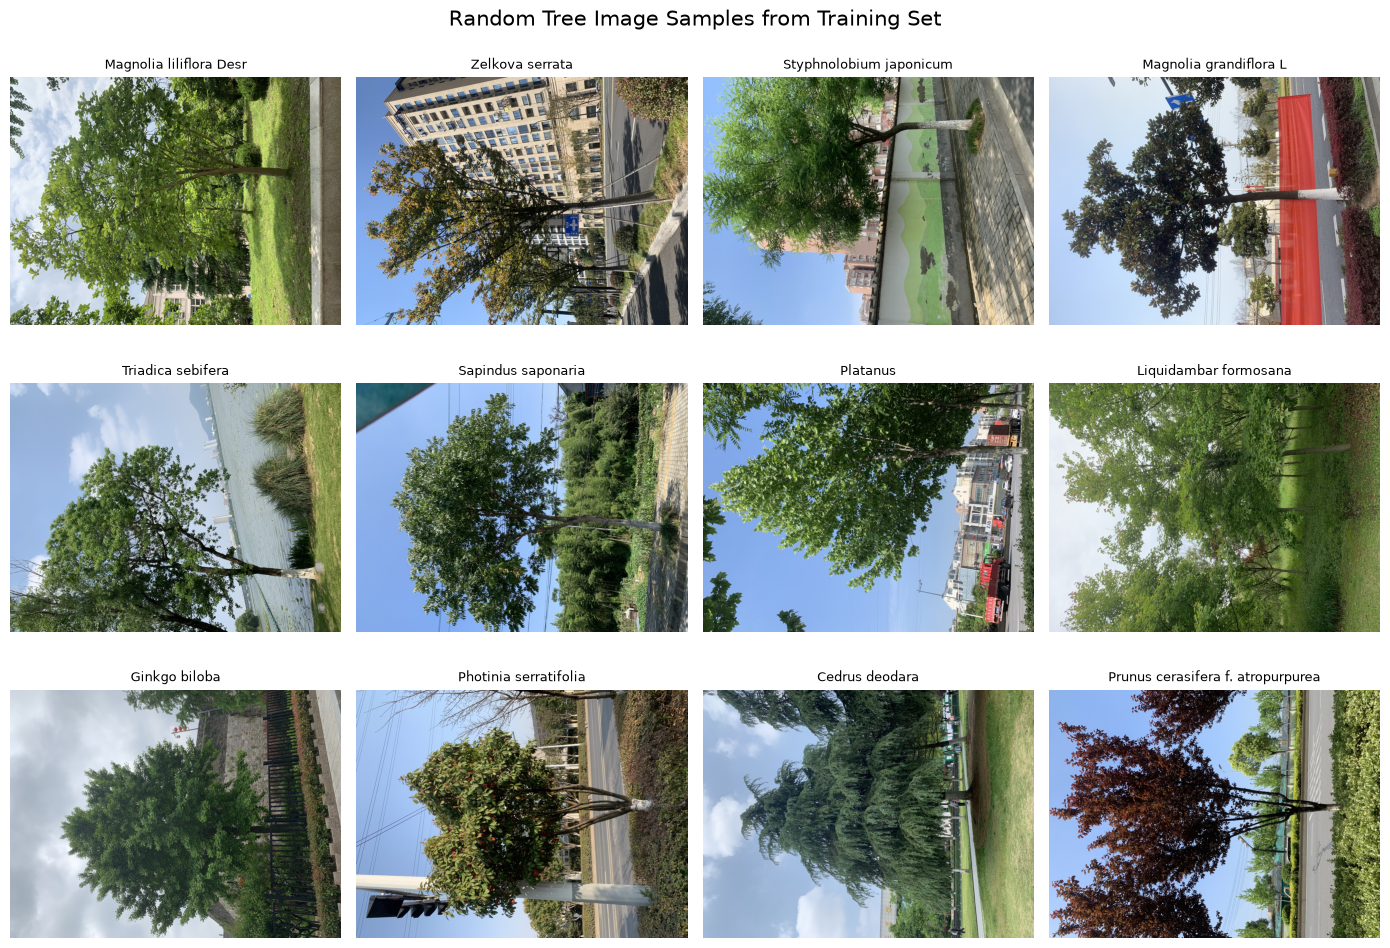

In [4]:
# Display a random selection of training images from different classes

samples = []
for class_name in class_dirs:
    folder = TRAIN_DIR / class_name
    files = [
        f for f in folder.iterdir()
        if f.is_file() and f.suffix.lower() in valid_extensions
    ]
    if files:
        chosen = random.choice(files)
        samples.append((class_name, chosen))

random.shuffle(samples)
samples = samples[:12]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, (label, path) in zip(axes.flat, samples):
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.suptitle("Random Tree Image Samples from Training Set", fontsize=15)
plt.tight_layout()
plt.show()


## 2. Preprocessing and data augmentation

The pretrained ResNet models expect images of a consistent size.

For training, a small amount of augmentation is used so that the model sees slightly different versions of the training images. Validation and test images are not randomly augmented because they should represent the actual evaluation data.

The ImageNet mean and standard deviation are used because the ResNet backbones are pretrained on ImageNet.

In [5]:
# Transforms

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [6]:
# Load the existing train/validation/test splits

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

# Make sure all splits contain the same classes and therefore use the same label mapping.
assert val_dataset.classes == class_names, "Validation classes do not match training classes."
assert test_dataset.classes == class_names, "Test classes do not match training classes."

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("Classes:", num_classes)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Classes: 23
Train: 3850
Validation: 482
Test: 472


## 3. Helper functions for training

Both models use the same training procedure so that the comparison is fair.

The pretrained convolutional layers are kept and the final classification layer is replaced with a new layer matching the number of tree species.

In [7]:
def build_resnet(model_name, num_classes):
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    else:
        raise ValueError("Use 'resnet18' or 'resnet50'.")

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    best_weights = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    for epoch in range(epochs):
        start = time.time()

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_total += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_total / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"train loss {train_loss:.4f} | train acc {train_acc:.3f} | "
            f"val loss {val_loss:.4f} | val acc {val_acc:.3f} | "
            f"{elapsed:.1f}s"
        )

    model.load_state_dict(best_weights)
    return model, history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

## 4. Model 1 — ResNet-18

ResNet-18 is the smaller of the two selected architectures. It provides a relatively lightweight baseline for the classification task.

Epoch 01/10 | train loss 1.7940 | train acc 0.475 | val loss 1.9258 | val acc 0.444 | 59.4s
Epoch 02/10 | train loss 1.0877 | train acc 0.665 | val loss 1.8867 | val acc 0.548 | 47.7s
Epoch 03/10 | train loss 0.8061 | train acc 0.749 | val loss 1.2120 | val acc 0.637 | 48.7s
Epoch 04/10 | train loss 0.6038 | train acc 0.813 | val loss 3.1172 | val acc 0.454 | 47.8s
Epoch 05/10 | train loss 0.5455 | train acc 0.829 | val loss 1.6627 | val acc 0.654 | 49.3s
Epoch 06/10 | train loss 0.4541 | train acc 0.854 | val loss 1.1199 | val acc 0.730 | 49.8s
Epoch 07/10 | train loss 0.3768 | train acc 0.877 | val loss 0.7786 | val acc 0.780 | 49.4s
Epoch 08/10 | train loss 0.3585 | train acc 0.883 | val loss 0.8717 | val acc 0.751 | 50.4s
Epoch 09/10 | train loss 0.2929 | train acc 0.907 | val loss 0.8001 | val acc 0.763 | 50.7s
Epoch 10/10 | train loss 0.2590 | train acc 0.919 | val loss 1.3408 | val acc 0.676 | 51.1s


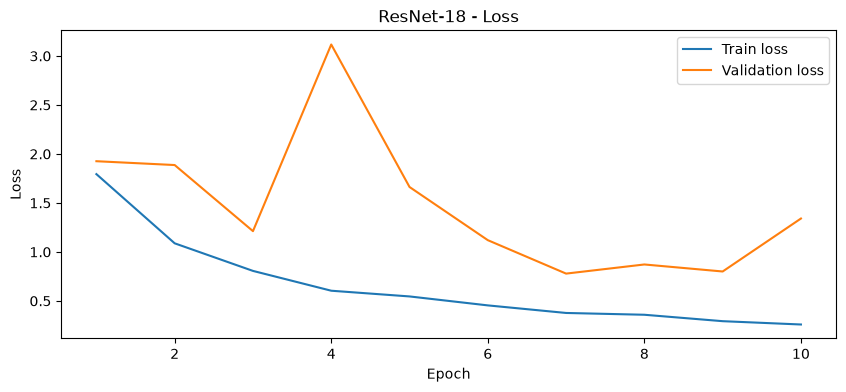

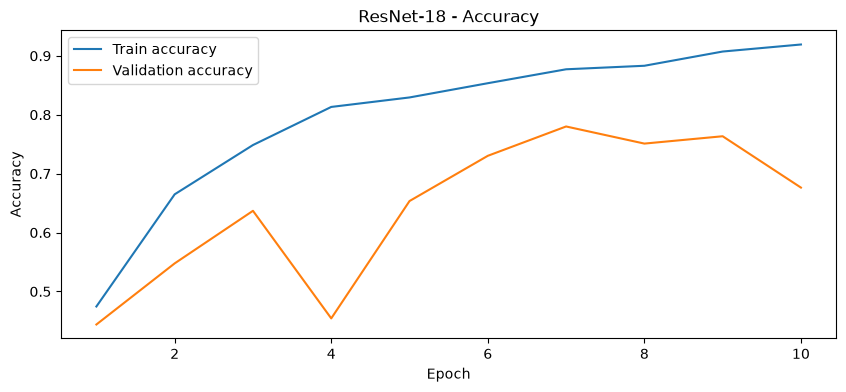

In [8]:
resnet18 = build_resnet("resnet18", num_classes)

# Train ResNet-18
resnet18, history18 = train_model(
    resnet18,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)

plot_history(history18, "ResNet-18")

## 5. Model 2 — ResNet-50

ResNet-50 is a deeper architecture than ResNet-18. It has more representational capacity, but it also requires more computation.

Epoch 01/10 | train loss 1.6522 | train acc 0.523 | val loss 1.2674 | val acc 0.637 | 53.2s
Epoch 02/10 | train loss 0.7093 | train acc 0.784 | val loss 1.2192 | val acc 0.658 | 52.6s
Epoch 03/10 | train loss 0.4811 | train acc 0.853 | val loss 0.6189 | val acc 0.842 | 51.2s
Epoch 04/10 | train loss 0.3647 | train acc 0.886 | val loss 0.6851 | val acc 0.797 | 51.8s
Epoch 05/10 | train loss 0.2820 | train acc 0.914 | val loss 0.5839 | val acc 0.826 | 51.9s
Epoch 06/10 | train loss 0.2257 | train acc 0.928 | val loss 0.4576 | val acc 0.851 | 52.3s
Epoch 07/10 | train loss 0.1996 | train acc 0.940 | val loss 1.0599 | val acc 0.741 | 51.7s
Epoch 08/10 | train loss 0.2118 | train acc 0.935 | val loss 0.5232 | val acc 0.851 | 51.9s
Epoch 09/10 | train loss 0.1464 | train acc 0.950 | val loss 0.3759 | val acc 0.880 | 52.4s
Epoch 10/10 | train loss 0.1313 | train acc 0.963 | val loss 0.5577 | val acc 0.838 | 52.2s


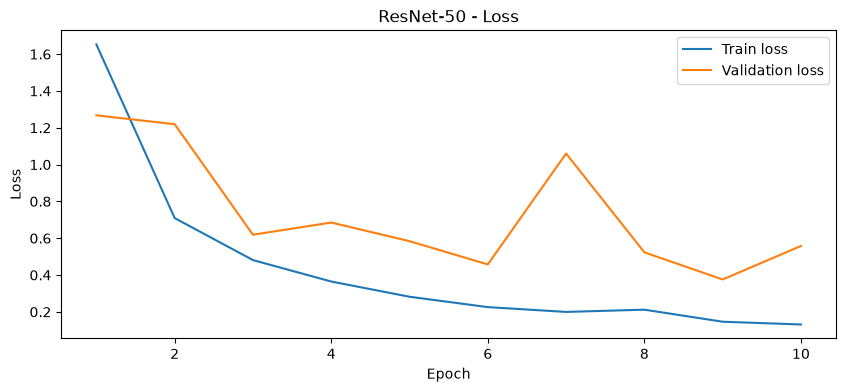

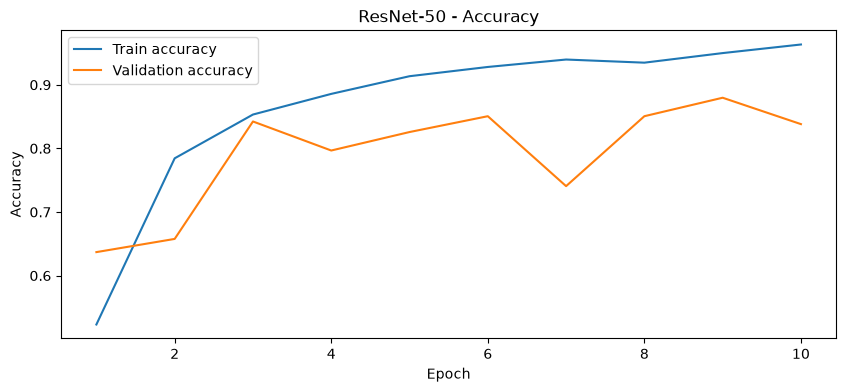

In [9]:
resnet50 = build_resnet("resnet50", num_classes)

# Train ResNet-50
resnet50, history50 = train_model(
    resnet50,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)

plot_history(history50, "ResNet-50")

## 6. Compare the two models

The validation curves help show whether a model is learning effectively and whether there are signs of overfitting.

In [10]:
comparison = pd.DataFrame({
    "Model": ["ResNet-18", "ResNet-50"],
    "Best validation accuracy": [
        max(history18["val_acc"]),
        max(history50["val_acc"])
    ],
    "Final validation accuracy": [
        history18["val_acc"][-1],
        history50["val_acc"][-1]
    ]
})

display(comparison)

,Model,Best validation accuracy,Final validation accuracy
0,ResNet-18,0.780083,0.676349
1,ResNet-50,0.879668,0.838174


## 7. Test-set evaluation

The test set is used only for the final evaluation.

The metrics below provide several views of classification performance. Macro averaging gives every species equal importance, which is useful when the number of images differs between classes.

In [11]:
def get_predictions(model, loader):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_probs.append(probs.cpu())

    return (
        np.array(all_labels),
        np.array(all_preds),
        torch.cat(all_probs).numpy()
    )


def evaluate_model(model, loader, name):
    labels, preds, probs = get_predictions(model, loader)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    results = {
        "Model": name,
        "Accuracy": accuracy_score(labels, preds),
        "Precision (macro)": precision,
        "Recall (macro)": recall,
        "F1-score (macro)": f1
    }

    return results, labels, preds, probs


result18, y18, p18, prob18 = evaluate_model(
    resnet18, test_loader, "ResNet-18"
)

result50, y50, p50, prob50 = evaluate_model(
    resnet50, test_loader, "ResNet-50"
)

test_results = pd.DataFrame([result18, result50])
display(test_results)

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,ResNet-18,0.726695,0.790481,0.743506,0.726134
1,ResNet-50,0.847458,0.867963,0.856691,0.850364


In [12]:
# Detailed per-class report for the stronger model

best_name = (
    "ResNet-18"
    if result18["F1-score (macro)"] >= result50["F1-score (macro)"]
    else "ResNet-50"
)

best_model = resnet18 if best_name == "ResNet-18" else resnet50
best_labels = y18 if best_name == "ResNet-18" else y50
best_preds = p18 if best_name == "ResNet-18" else p50

print("Best model according to macro F1:", best_name)
print()

print(classification_report(
    best_labels,
    best_preds,
    labels=list(range(num_classes)),
    target_names=class_names,
    zero_division=0
))

Best model according to macro F1: ResNet-50

                                   precision    recall  f1-score   support

                    Acer palmatum       0.86      0.90      0.88        20
                   Cedrus deodara       0.65      1.00      0.79        15
                  Celtis sinensis       1.00      0.57      0.72        23
 Cinnamomum camphora (Linn) Presl       0.89      0.83      0.86        29
            Elaeocarpus decipiens       0.79      0.90      0.84        21
                 Flowering cherry       0.77      0.77      0.77        13
                    Ginkgo biloba       0.96      0.79      0.86        28
          Koelreuteria paniculata       1.00      0.71      0.83        28
             Lagerstroemia indica       0.89      1.00      0.94         8
            Liquidambar formosana       0.76      0.95      0.84        20
            Liriodendron chinense       0.79      1.00      0.88        22
           Magnolia grandiflora L       0.96      0.96

## 8. Confusion matrices

A confusion matrix shows which species are confused with one another.

Large values away from the diagonal indicate classes that the model frequently mistakes for another species.

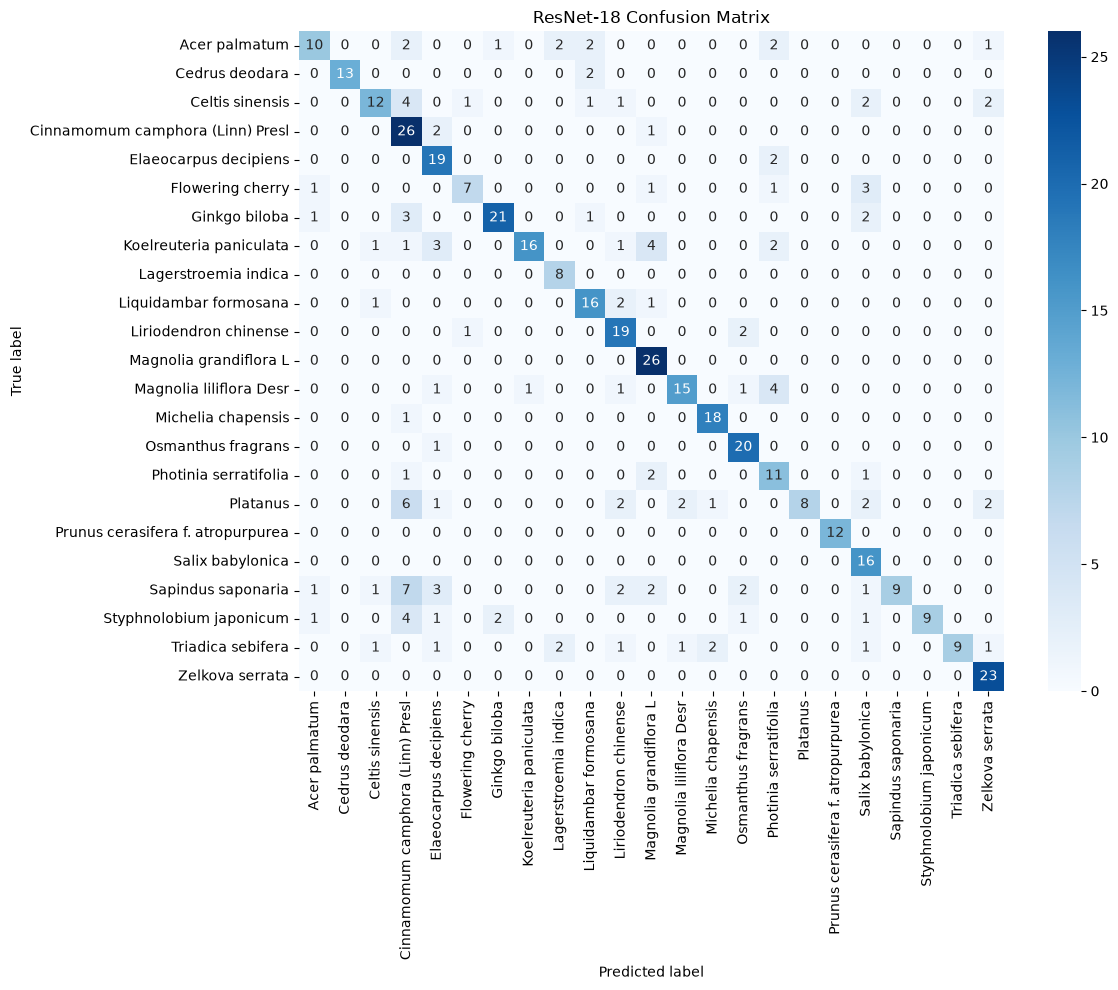

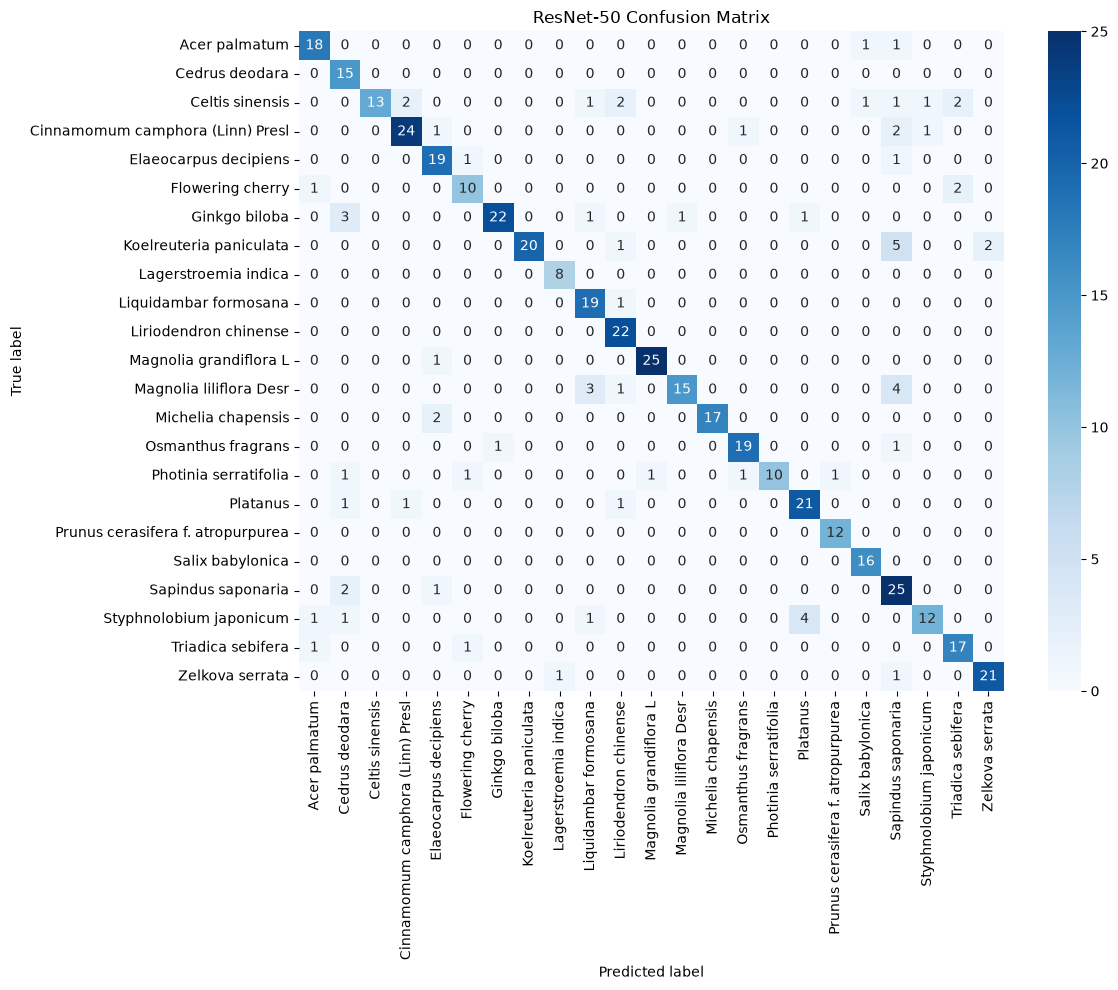

In [13]:
def show_confusion_matrix(labels, preds, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

show_confusion_matrix(y18, p18, "ResNet-18 Confusion Matrix")
show_confusion_matrix(y50, p50, "ResNet-50 Confusion Matrix")

## 9. n-best / Top-n classification

The assignment asks us to investigate whether the models differ when more than the single highest-probability prediction is considered.

For example, Top-5 accuracy is the percentage of test images where the correct species appears somewhere among the five highest model predictions.

,n,ResNet-18,ResNet-50
0,1,0.726695,0.847458
1,2,0.832627,0.887712
2,3,0.891949,0.917373
3,4,0.923729,0.930085
4,5,0.947034,0.947034
5,6,0.959746,0.961864
6,7,0.968220,0.968220
7,8,0.968220,0.974576
8,9,0.976695,0.978814
9,10,0.980932,0.980932


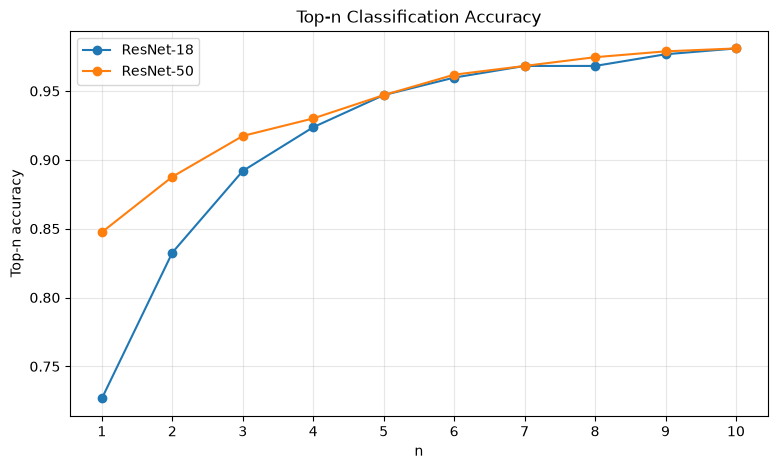

In [14]:
def top_n_accuracy(labels, probabilities, n):
    top_n = np.argsort(probabilities, axis=1)[:, -n:]
    return np.mean([
        label in predictions
        for label, predictions in zip(labels, top_n)
    ])


n_values = list(range(1, min(10, num_classes) + 1))

topn_table = []
for n in n_values:
    topn_table.append({
        "n": n,
        "ResNet-18": top_n_accuracy(y18, prob18, n),
        "ResNet-50": top_n_accuracy(y50, prob50, n)
    })

topn_df = pd.DataFrame(topn_table)
display(topn_df)

plt.figure(figsize=(9, 5))
plt.plot(topn_df["n"], topn_df["ResNet-18"], marker="o", label="ResNet-18")
plt.plot(topn_df["n"], topn_df["ResNet-50"], marker="o", label="ResNet-50")
plt.xlabel("n")
plt.ylabel("Top-n accuracy")
plt.title("Top-n Classification Accuracy")
plt.xticks(n_values)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Interpreting the n-best results

The table and graph above should be discussed in the report.

Look for values of **n** where the difference between the models becomes meaningful. It is also possible that no single n clearly separates the models; if that happens, report that finding rather than forcing a conclusion.

## 10. Error analysis

The numerical metrics tell us how often the models fail, but not necessarily *why*.

The following section displays examples where the best model made an incorrect prediction. Inspect these images and look for repeated patterns such as similar-looking species, difficult backgrounds, unusual viewpoints, or image-quality problems.

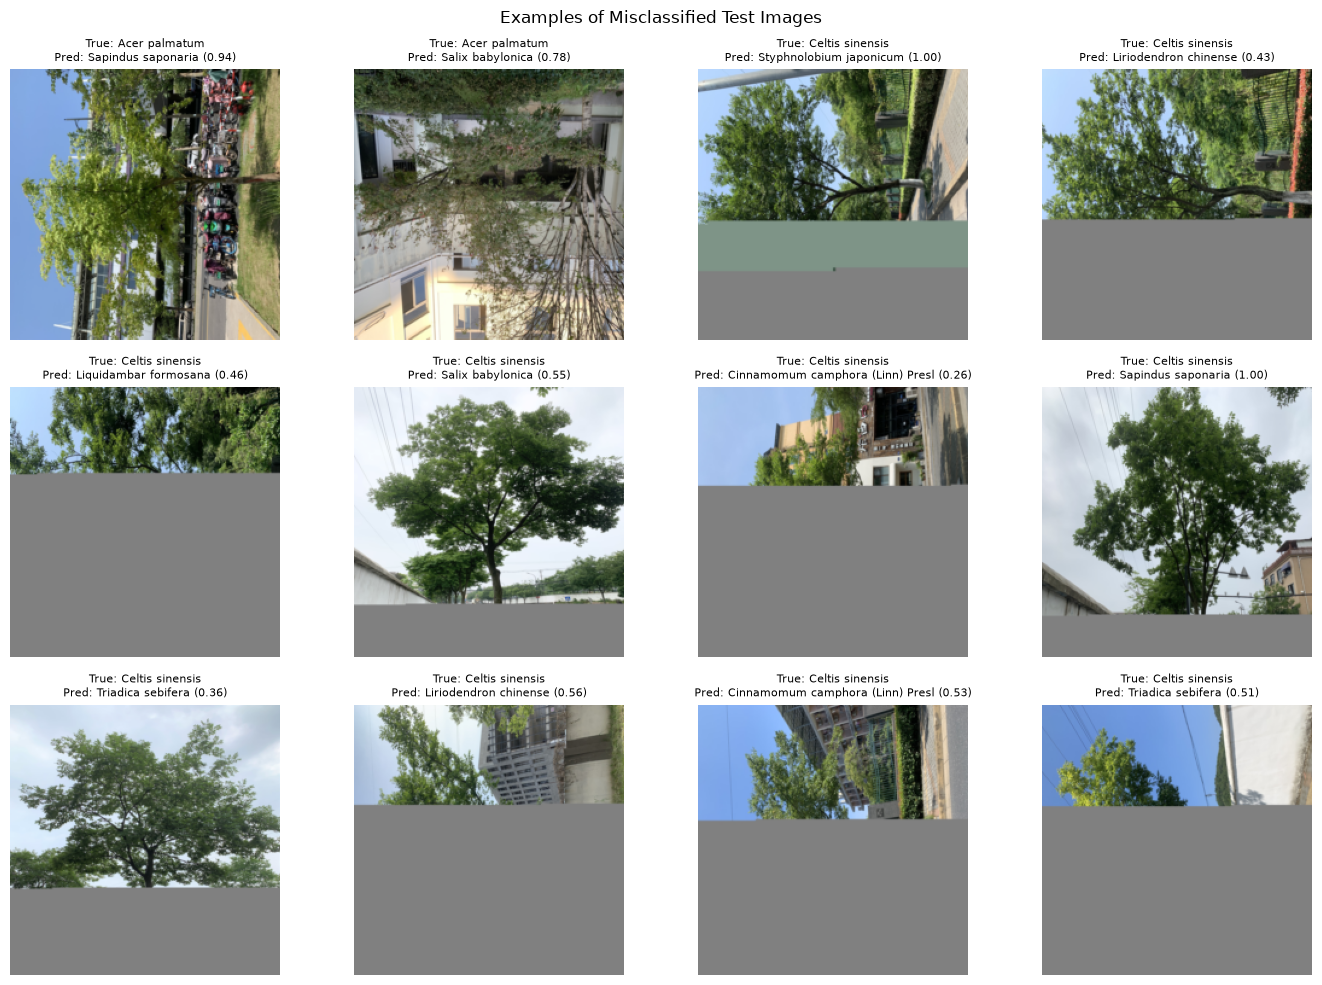

In [15]:
def show_misclassified(model, loader, max_images=12):
    model.eval()
    mistakes = []

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(DEVICE))
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(1).cpu()

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    mistakes.append((
                        images[i].cpu(),
                        labels[i].item(),
                        preds[i].item(),
                        probs[i].max().item()
                    ))

                if len(mistakes) >= max_images:
                    break

            if len(mistakes) >= max_images:
                break

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))

    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)

    for ax, (image, true_idx, pred_idx, confidence) in zip(axes.flat, mistakes):
        image = image * std + mean
        image = torch.clamp(image, 0, 1)

        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(
            f"True: {class_names[true_idx]}\n"
            f"Pred: {class_names[pred_idx]} ({confidence:.2f})",
            fontsize=8
        )
        ax.axis("off")

    for ax in axes.flat[len(mistakes):]:
        ax.axis("off")

    plt.suptitle("Examples of Misclassified Test Images")
    plt.tight_layout()
    plt.show()

show_misclassified(best_model, test_loader)

## 11. Improvement experiment

The project requires an attempt to improve the model.

Here we use stronger training augmentation as a simple, reproducible improvement. The purpose is not to assume that augmentation will definitely improve the result; instead, the new validation/test results should be compared with the original model.

If the improvement makes performance worse, that is still a useful result to discuss.

Epoch 01/10 | train loss 2.1796 | train acc 0.352 | val loss 2.6425 | val acc 0.313 | 59.6s
Epoch 02/10 | train loss 1.4880 | train acc 0.541 | val loss 2.8363 | val acc 0.407 | 57.8s
Epoch 03/10 | train loss 1.1693 | train acc 0.641 | val loss 0.9145 | val acc 0.730 | 55.6s
Epoch 04/10 | train loss 1.0326 | train acc 0.669 | val loss 1.1684 | val acc 0.649 | 55.1s
Epoch 05/10 | train loss 0.8629 | train acc 0.735 | val loss 1.1001 | val acc 0.678 | 55.1s
Epoch 06/10 | train loss 0.7997 | train acc 0.751 | val loss 1.2645 | val acc 0.608 | 54.7s
Epoch 07/10 | train loss 0.6815 | train acc 0.789 | val loss 1.1870 | val acc 0.649 | 56.1s
Epoch 08/10 | train loss 0.6627 | train acc 0.786 | val loss 1.6589 | val acc 0.566 | 56.6s
Epoch 09/10 | train loss 0.5879 | train acc 0.816 | val loss 0.9458 | val acc 0.757 | 56.0s
Epoch 10/10 | train loss 0.5758 | train acc 0.817 | val loss 1.4850 | val acc 0.660 | 55.9s


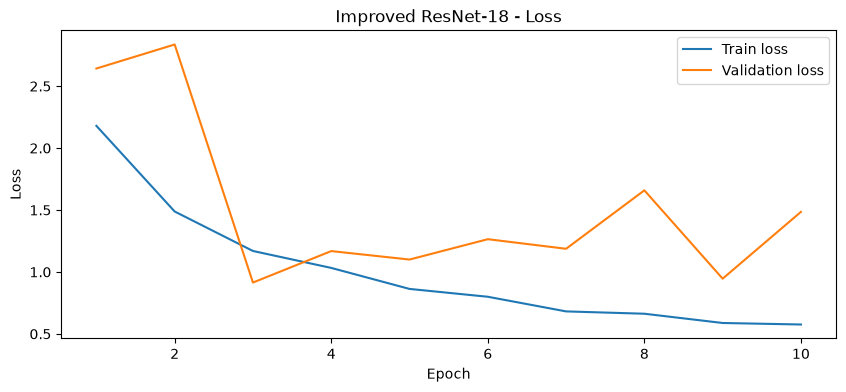

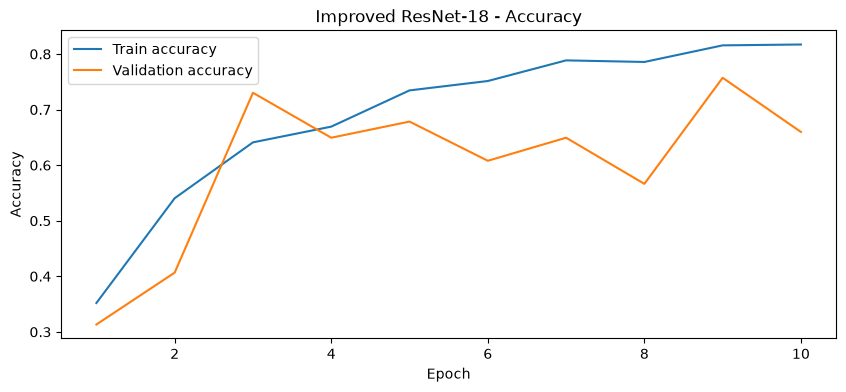

In [18]:
# Stronger augmentation experiment

improved_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(18),
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.25,
        hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

improved_train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=improved_train_transform
)

improved_train_loader = DataLoader(
    improved_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

improved_resnet18 = build_resnet("resnet18", num_classes)

improved_resnet18, improved_history = train_model(
    improved_resnet18,
    improved_train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)

plot_history(improved_history, "Improved ResNet-18")


In [20]:
# Compare original and improved ResNet-18

improved_result, _, _, _ = evaluate_model(
    improved_resnet18, test_loader, "ResNet-18 + stronger augmentation"
)

improvement_comparison = pd.DataFrame([
    result18,
    improved_result
])

display(improvement_comparison)

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,ResNet-18,0.726695,0.790481,0.743506,0.726134
1,ResNet-18 + stronger augmentation,0.690678,0.777177,0.707395,0.707064
